# Downloading and Mosaicking L1GT Landsat Scenes via USGS LandsatLook

Earth Search (Element84) only indexes **L1TP** (Tier 1) and **L2SP** Landsat scenes.
Polar scenes over glaciers are often processed as **L1GT** (lower geometric accuracy
due to sparse ground control), which means they are absent from Earth Search.

The `itslive_cloudfree` downloader falls back automatically to the
**USGS LandsatLook STAC** (`https://landsatlook.usgs.gov/stac-server`), which
carries the complete Landsat Collection 2 archive including L1GT scenes.
Assets require a free USGS ERS account — run `itslive-usgs-login` once to
save a session cookie, then point rasterio at it via `GDAL_HTTP_COOKIEFILE`.

A single Landsat scene only partially covers the search bbox. This notebook
demonstrates querying all same-path scenes acquired on the same day and
mosaicking them for full coverage.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime
from pathlib import Path

import rasterio
import pystac_client

from itslive_cloudfree.results import SceneResult
from itslive_cloudfree.downloader import download_scenes_mosaic
from itslive_cloudfree.scene_parser import parse_scene_id

## 1 — Authenticate

Run `itslive-usgs-login` in a terminal once to save `~/.usgs_landsat_cookies.txt`.

In [3]:
COOKIE_FILE = str(Path.home() / ".usgs_landsat_cookies.txt")
assert Path(COOKIE_FILE).exists(), (
    f"Cookie file not found: {COOKIE_FILE}\n"
    "Run  itslive-usgs-login  in a terminal first."
)

## 2 — Define search parameters

In [4]:
# Bounding box in EPSG:3031 (Antarctic Polar Stereographic, metres).
# Working in the native polar CRS avoids the non-rectangular footprint
# problem that arises when using a WGS-84 bbox for polar data.
#
# Approximate EPSG:3031 extent of the Pine Island Glacier search area
# (derived from the scene extents found above):
BBOX = (-1_660_000, -365_000, -1_490_000, -235_000)
BBOX_CRS = 3031

WRS_PATH = 229
DATE = "2019-12-29"
OUT_DIR = Path("l1gt_images")

## 3 — Find all same-path scenes that intersect the bbox

Multiple adjacent rows from the same Landsat path acquired on the same day
can be mosaicked together for better coverage.

In [5]:
usgs = pystac_client.Client.open("https://landsatlook.usgs.gov/stac-server")

# Convert the EPSG:3031 bbox to WGS-84 for the STAC spatial query.
from itslive_cloudfree.crs_utils import bbox_to_wgs84
search_bbox_wgs84 = bbox_to_wgs84(BBOX, BBOX_CRS)
# Expand slightly to catch adjacent rows.
search_bbox = (
    search_bbox_wgs84[0] - 5, search_bbox_wgs84[1] - 3,
    search_bbox_wgs84[2] + 5, search_bbox_wgs84[3] + 3,
)

items = list(usgs.search(
    collections=["landsat-c2l1"],
    bbox=list(search_bbox),
    datetime=f"{DATE}/{DATE}",
    max_items=50,
).items())

def bbox_overlaps_3031(item_wgs84_bbox):
    """Check overlap in EPSG:3031 to avoid WGS-84 bbox distortion issues."""
    from itslive_cloudfree.crs_utils import bbox_to_wgs84, transform_bbox
    item_3031 = transform_bbox(item_wgs84_bbox, 4326, 3031)
    a, b = item_3031, BBOX
    return a[0] < b[2] and a[2] > b[0] and a[1] < b[3] and a[3] > b[1]

scenes = []
for item in items:
    props = item.properties
    if props.get("landsat:wrs_path") != str(WRS_PATH):
        continue
    if not bbox_overlaps_3031(item.bbox):
        continue
    parsed = parse_scene_id(item.id, props.get("platform", ""))
    if parsed is None:
        continue
    scenes.append(SceneResult(
        scene_id=item.id,
        platform=parsed.platform,
        acquisition_date=parsed.acquisition_date,
        path_row=parsed.path_row,
        tile=parsed.tile,
        pair_count=0,
        mean_valid_pixels=0.0,
        cloud_free_score=0.0,
    ))

print(f"Found {len(scenes)} scene(s) for path {WRS_PATH} on {DATE}:")
for s in scenes:
    print(f"  {s.scene_id}  ({s.path_row})")

Found 2 scene(s) for path 229 on 2019-12-29:
  LC08_L1GT_229115_20191229_20201016_02_T2  (229/115)
  LC08_L1GT_229114_20191229_20201016_02_T2  (229/114)


## 4 — Download, mosaic, and reproject in one step

`download_scenes_mosaic` resolves the STAC asset URLs for all scenes, then
calls `gdal.Warp()` with the full list of COG hrefs. GDAL builds an internal
VRT mosaic and reprojects to the target CRS in a single pass — no intermediate
files are written.

In [14]:
with rasterio.Env(GDAL_HTTP_COOKIEFILE=COOKIE_FILE, GDAL_HTTP_COOKIEJAR=COOKIE_FILE):
    mosaic_paths = download_scenes_mosaic(
        scenes,
        bbox=BBOX,
        bbox_crs=BBOX_CRS,
        dst_crs=3031,
        out_dir=OUT_DIR,
    )

for band, path in mosaic_paths.items():
    with rasterio.open(path) as src:
        print(f"{band}: {src.width}x{src.height} px  CRS=EPSG:{src.crs.to_epsg()}  → {path.name}")

red: 7760x4154 px  CRS=3031  → LC08_229-115_229-114_20191229_B4.tif
green: 7760x4154 px  CRS=3031  → LC08_229-115_229-114_20191229_B3.tif
blue: 7760x4154 px  CRS=3031  → LC08_229-115_229-114_20191229_B2.tif
nir08: 7760x4154 px  CRS=3031  → LC08_229-115_229-114_20191229_B5.tif


## 6 — Quick look

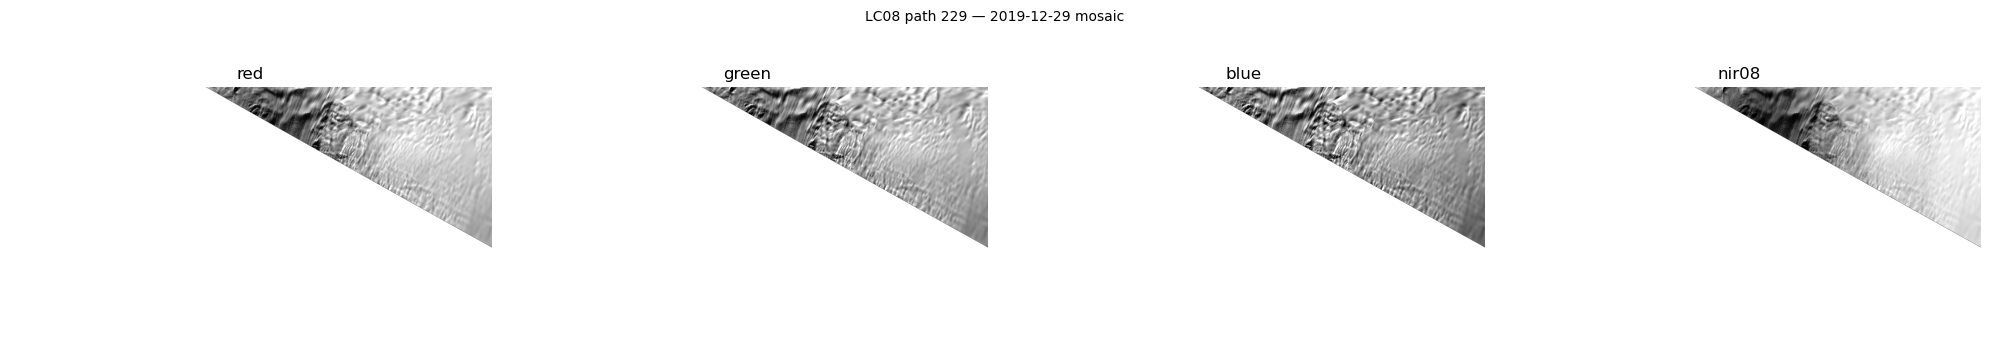

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(mosaic_paths), figsize=(5 * len(mosaic_paths), 4))
if len(mosaic_paths) == 1:
    axes = [axes]

for ax, (band, path) in zip(axes, mosaic_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
    data[data == 0] = np.nan
    p2, p98 = np.nanpercentile(data, [2, 98])
    ax.imshow(data, vmin=p2, vmax=p98, cmap="gray")
    ax.set_title(band)
    ax.axis("off")

fig.suptitle(f"LC08 path {WRS_PATH} — {DATE} mosaic", fontsize=10)
plt.tight_layout()
plt.show()

In [16]:
path

PosixPath('l1gt_images/LC08_229-115_229-114_20191229_B5.tif')